In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing_extensions import Annotated
from typing import TypedDict
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()



True

In [2]:
## object of llm
llm_g = ChatGoogleGenerativeAI(
            model = "gemini-3.5-flash-lite"
)

In [4]:
## create state
class State(TypedDict): ## dictionary output
    messages: Annotated[list, add_messages] # list of messages will be added everytime

In [6]:
## create tools
def mul(a: int, b:int):
    """
    Perform a simple mathematical operations such as Multiplication.

    Args:
        a (int): 1st Integer number
        b (int): 2nd Integer number

    Return:
        Output is also an integer
    """
    output = a*b
    return output

def add(a: int, b:int):
    """
    Perform a simple mathematical operations such as Addition.

    Args:
        a (int): 1st Integer number
        b (int): 2nd Integer number

    Return:
        Output is also an integer
    """
    output = a+b
    return output

In [8]:
## list of tools
tools_list = [add, mul]

In [9]:
## bind the tools with llm
llm_g_tools = llm_g.bind_tools(tools=tools_list)

In [10]:
## call the tools and llm perform task
def tool_call_llm(state: State):
    return {"messages": [llm_g_tools.invoke(state['messages'])]}

In [13]:
## set the graph
graph_builder = StateGraph(State)

memory_check = MemorySaver()
## create node
graph_builder.add_node("math_tool_call_llm", tool_call_llm)
graph_builder.add_node("tools", ToolNode(tools_list))

## create edges
graph_builder.add_edge(START, "math_tool_call_llm")
graph_builder.add_conditional_edges(
    "math_tool_call_llm", tools_condition
)
graph_builder.add_edge("tools", "math_tool_call_llm")

## compile the graph
graph_bot = graph_builder.compile(checkpointer=memory_check)

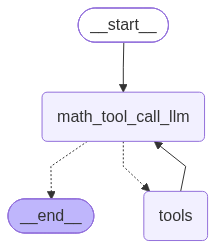

In [14]:
graph_bot

In [19]:
## configuration thread
configs = {"configurable": {"thread_id":"memory_id"}}

## set the config
response = graph_bot.invoke({"messages":["My name is Saroj"]}, config=configs)

response["messages"][-1].text

"Hello Saroj! It's nice to meet you. How can I help you today?"